#### **Assignment 3: Regularization and Distances**

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 25 April 2026*

**Methodology**

**Part 1: Regularization**

**Dataset**
- The Human Activity Recognition dataset, with 561 engineered features
- Chosen because
    1) the number of features allows a implementation of regularization
    2) many features represent different transformations of the same underlying signals, leading to strong redundancy and correlation

**Regularization methods**
- Ridge: retains all features while shrinking their coeeficients, leading to more stable models 
    $$\min_{\beta} \|y - X\beta\|^2 + \lambda \|\beta\|_2^2$$
- Lasso: reduces number of active features, effective feature selection
$$
\min_{\beta} \|y - X\beta\|^2 + \lambda \|\beta\|_1
$$
- ElasticNet: compromise, preserves groups of features while still reducing sparsity 
$$
\min_{\beta} \|y - X\beta\|^2 + \lambda \left( \alpha \|\beta\|_1 + (1-\alpha)\|\beta\|_2^2 \right)
$$  
**Part 2: Distances and Clustering**
- Unsupervised clustering on DNA-like sequences with unknown labels
- Goal: discover hidden biological structure across potentially multiple organisms

**Sequence Representation**
- k-mer frequencies (k=3): 64-dimensional compositional vector per sequence
- Normalised Hamming distance: position-aware pairwise dissimilarity, non-Euclidean, bounded [0,1]

**Clustering**
- Hierarchical clustering (average linkage) on both distance matrices
- HDBSCAN on Hamming matrix, density-based with no assumed cluster count
- Multiple methods used to cross-validate discovered structure

**Validation & Interpretation**
- Silhouette, Davies-Bouldin, and Calinski-Harabasz scores across all clusterings
- Per-cluster GC content, nucleotide frequencies, and medoid sequences for biological interpretation

#### **1. Regularization Study**

**Importing necessary libraries**

In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter

**Loading the dataset**

In [69]:
# Load HAR dataset
har = fetch_openml(name="HAR", version=1, as_frame=True)

df = har.frame

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

print(X.shape)  
print(y.value_counts())

(10299, 561)
Class
6    1944
5    1906
4    1777
1    1722
2    1544
3    1406
Name: count, dtype: int64


**EDA**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 561 entries, V1 to V561
dtypes: float64(561)
memory usage: 44.1 MB
None
      count      mean       std  min       25%       50%       75%  max
V1  10299.0  0.274347  0.067628 -1.0  0.262624  0.277174  0.288354  1.0
V2  10299.0 -0.017743  0.037128 -1.0 -0.024903 -0.017162 -0.010625  1.0
V3  10299.0 -0.108925  0.053033 -1.0 -0.121019 -0.108596 -0.097589  1.0
V4  10299.0 -0.607784  0.438694 -1.0 -0.992360 -0.943030 -0.250293  1.0
V5  10299.0 -0.510191  0.500240 -1.0 -0.976990 -0.835032 -0.057336  1.0
0


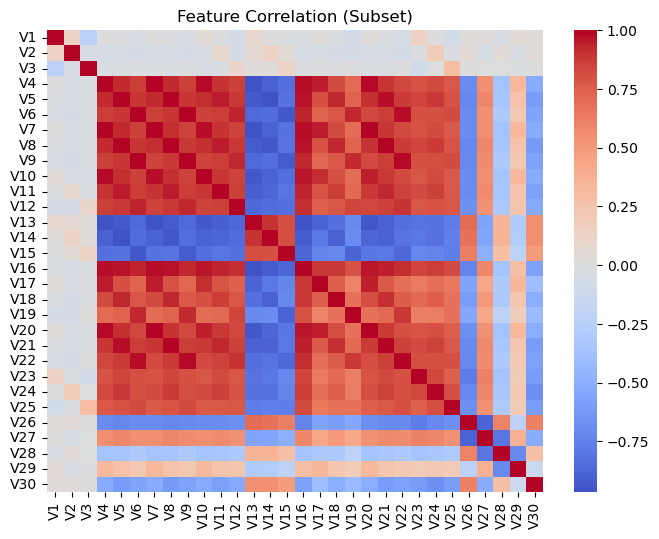

In [70]:
# Basic info
print(X.info())
print(X.describe().T.head())

# Check missing values
print(X.isnull().sum().sum())

# Correlation (subset to avoid huge plot)

subset = X.iloc[:, :30]  # first 30 features
plt.figure(figsize=(8, 6))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation (Subset)")
plt.show()

**Pre-processing**

In [71]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling with StandardScaler (mean=0, std=1) 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Define Models** 

In [72]:



# Ridge
def do_ridge(lambdaaa):
    ridge = Ridge(alpha=lambdaaa, max_iter = 5000)
    
    ridge.fit(X_train_scaled, y_train)
    
    ridge_train_score = ridge.score(X_train_scaled, y_train)
    ridge_test_score = ridge.score(X_test_scaled, y_test)
    ridge_num_features = np.sum(ridge.coef_ != 0)
    ridge_coef = ridge.coef_
    
    return [round(lambdaaa, 4), round(ridge_train_score, 4), 
            round(ridge_test_score, 4), ridge_num_features], list(ridge_coef)

# LASSO
def do_lasso(lambdaaa):
    lasso = Lasso(alpha=lambdaaa, max_iter = 5000)
    lasso.fit(X_train_scaled, y_train)
    
    lasso_train_score = lasso.score(X_train_scaled, y_train)
    lasso_test_score = lasso.score(X_test_scaled, y_test)
    lasso_num_features = np.sum(lasso.coef_ != 0)
    lasso_coef = lasso.coef_
    
    return [round(lambdaaa, 4), round(lasso_train_score, 4), 
            round(lasso_test_score, 4), lasso_num_features], list(lasso_coef)

# Elastic Net
def do_elastic(lambdaaa):
    elast = ElasticNet(alpha=lambdaaa, l1_ratio=0.5, max_iter = 5000)
    elast.fit(X_train_scaled, y_train)
    
    elast_train_score = elast.score(X_train_scaled, y_train)
    elast_test_score = elast.score(X_test_scaled, y_test)
    elast_num_features = np.sum(elast.coef_ != 0)
    elast_coef = elast.coef_
    
    return [round(lambdaaa, 4), round(elast_train_score, 4), 
            round(elast_test_score, 4), elast_num_features], list(elast_coef)

- We evaluate models over a range of regularization strengths to analyze how feature selection behavior and predictive performance evolve.

- For ElasticNet, we fix the L1 ratio to 0.5 to balance sparsity and stability, allowing us to isolate the effect of the regularization strength.

**Ridge (L2)** 

In [73]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_ridge(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

ridge_results = pd.concat([temp_1, temp_2], axis=1)
ridge_results.head()

,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9738,0.9712,561,-0.018893,0.011632,0.003055,0.631556,0.415080,1.366678,...,0.041101,-0.047685,0.024672,-0.003330,-0.007474,0.026700,0.005896,-1.052732,-0.454444,-0.355292
1,0.0346,0.9738,0.9712,561,-0.018324,0.011756,0.003188,0.668149,0.295581,1.024470,...,0.041870,-0.050743,0.027641,-0.003595,-0.006916,0.026493,0.005694,-1.037831,-0.443912,-0.356075
2,0.0691,0.9737,0.9712,561,-0.017944,0.011808,0.003146,0.569489,0.127823,0.794241,...,0.042001,-0.052558,0.029328,-0.003677,-0.006634,0.026421,0.005617,-1.026730,-0.437699,-0.355256
3,0.1035,0.9737,0.9712,561,-0.017719,0.011855,0.003086,0.492980,0.018591,0.641012,...,0.042023,-0.053835,0.030512,-0.003728,-0.006436,0.026384,0.005565,-1.016973,-0.432736,-0.354137
4,0.1380,0.9736,0.9712,561,-0.017578,0.011907,0.003026,0.437390,-0.056836,0.532228,...,0.042000,-0.054802,0.031413,-0.003759,-0.006283,0.026359,0.005527,-1.008013,-0.428487,-0.352910


**Lasso (L1)**

In [74]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_lasso(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

lasso_results = pd.concat([temp_1, temp_2], axis=1)
lasso_results.head()

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.011e+02, tolerance: 2.505e+00
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9726,0.9704,423,-0.013402,0.01323,0.001735,0.000268,-1.137897,-0.004004,...,0.037515,-0.06522,0.045204,-0.002185,-0.003956,0.025382,0.005634,-0.826487,-0.323792,-0.28693
1,0.0346,0.9302,0.9312,48,0.000000,0.00000,0.000000,-0.000000,-0.000000,-0.000000,...,-0.020557,-0.00000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,-0.00000
2,0.0691,0.9060,0.9073,30,0.000000,0.00000,0.000000,0.000000,-0.000000,-0.000000,...,-0.009662,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
3,0.1035,0.8762,0.8786,14,-0.000000,0.00000,0.000000,-0.000000,-0.000000,-0.000000,...,-0.000000,-0.00000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.00000
4,0.1380,0.8487,0.8519,11,-0.000000,0.00000,0.000000,-0.000000,-0.000000,-0.000000,...,-0.000000,-0.00000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000,-0.000000,-0.00000


**Elastic Net**

In [75]:
results, coefficient = [], []

for i in np.linspace(0.0001, 1, 30):
    run, coef_run = do_elastic(i)
    results.append(run)
    coefficient.append(coef_run)

temp_1 = pd.DataFrame(results, columns=["Lambda", "Train Score", "Test Score", "Number of features"])
temp_2 = pd.DataFrame(coefficient, columns=X.columns)

elastic_results = pd.concat([temp_1, temp_2], axis=1)
elastic_results.head()

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.365e+02, tolerance: 2.505e+00
  model = cd_fast.enet_coordinate_descent(


,Lambda,Train Score,Test Score,Number of features,V1,V2,V3,V4,V5,V6,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
0,0.0001,0.9728,0.9706,461,-0.016024,0.01325,0.00199,-0.232124,-0.954130,-0.10294,...,0.039449,-0.064939,0.043377,-0.002981,-0.004456,0.025612,0.00552,-0.852756,-0.346023,-0.299657
1,0.0346,0.9426,0.9435,95,0.000000,0.00000,0.00000,-0.000000,-0.004704,-0.00000,...,-0.020309,-0.000000,-0.004519,-0.000000,-0.000000,0.007634,0.00000,0.000000,0.000000,-0.000000
2,0.0691,0.9293,0.9299,71,0.000000,0.00000,0.00000,-0.000000,-0.000000,-0.00000,...,-0.021768,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.00000,0.000000,0.000000,-0.000000
3,0.1035,0.9171,0.9174,57,0.000000,0.00000,0.00000,-0.000000,-0.000000,-0.00000,...,-0.014615,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.00000,0.000000,-0.000000,-0.000000
4,0.1380,0.9029,0.9032,52,0.000000,0.00000,0.00000,-0.000000,-0.000000,-0.00000,...,-0.006470,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.00000,0.000000,-0.000000,-0.000000


**Cross validation**

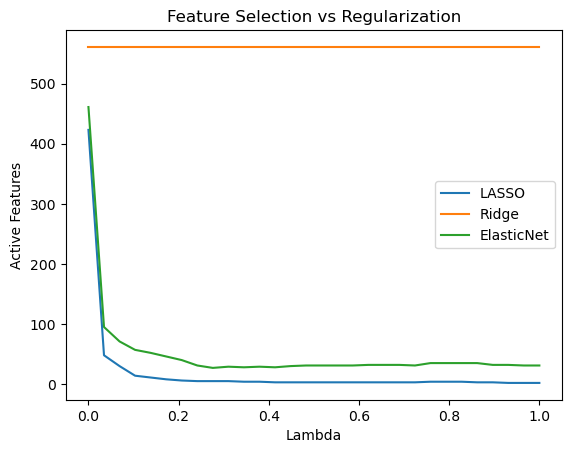

In [76]:
# number of features
plt.plot(lasso_results["Lambda"], lasso_results["Number of features"], label="LASSO")
plt.plot(ridge_results["Lambda"], ridge_results["Number of features"], label="Ridge")
plt.plot(elastic_results["Lambda"], elastic_results["Number of features"], label="ElasticNet")

plt.xlabel("Lambda")
plt.ylabel("Active Features")
plt.title("Feature Selection vs Regularization")
plt.legend()
plt.show()


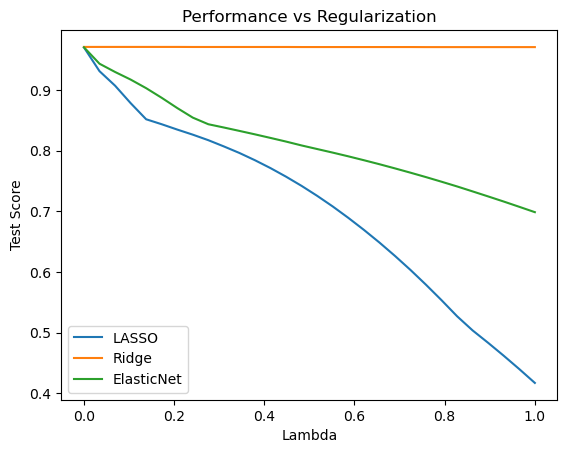

In [77]:
# train and test score
plt.plot(lasso_results["Lambda"], lasso_results["Test Score"], label="LASSO")
plt.plot(ridge_results["Lambda"], ridge_results["Test Score"], label="Ridge")
plt.plot(elastic_results["Lambda"], elastic_results["Test Score"], label="ElasticNet")

plt.xlabel("Lambda")
plt.ylabel("Test Score")
plt.title("Performance vs Regularization")
plt.legend()
plt.show()

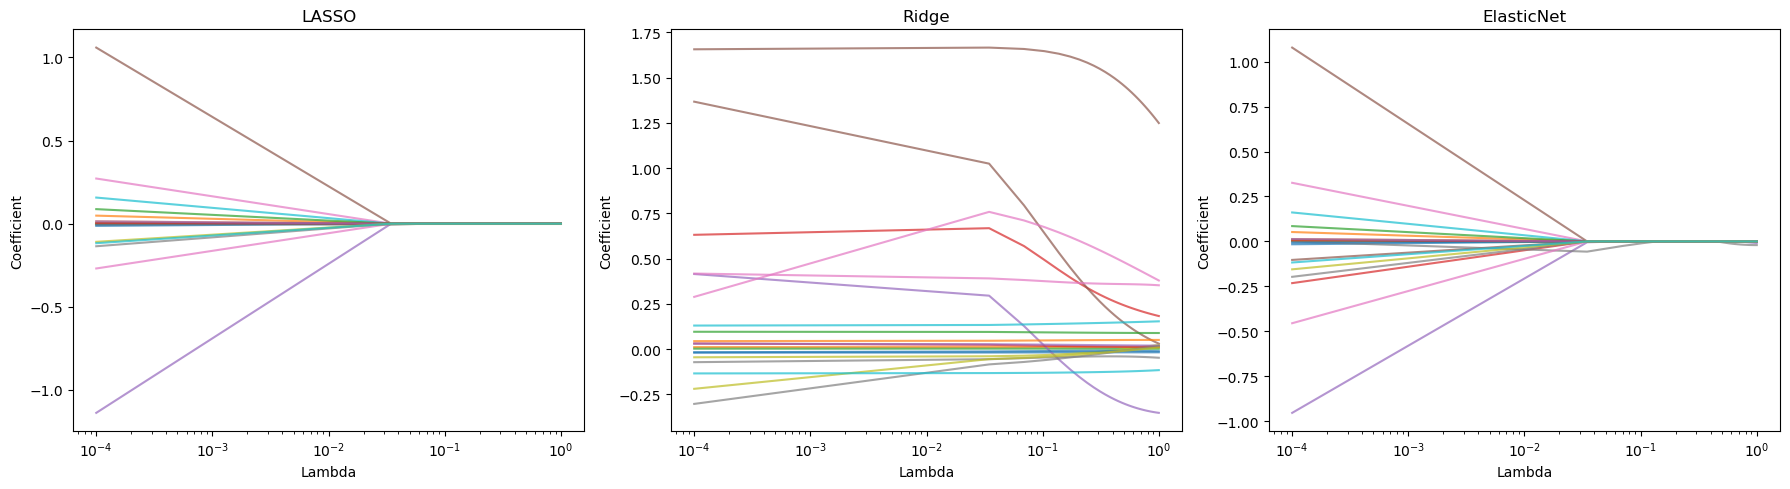

In [78]:
# coefficient path
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_names = ["LASSO", "Ridge", "ElasticNet"]
plot_data = [lasso_results, ridge_results, elastic_results]

for ax, name, data in zip(axes, plot_names, plot_data):
    
    for column in X.columns[:20]:
        ax.plot(data["Lambda"], data[column], alpha=0.7)
    
    ax.set_xscale("log")
    ax.set_title(name)
    ax.set_xlabel("Lambda")
    ax.set_ylabel("Coefficient")

plt.tight_layout()
plt.show()

**Feature Selection Analysis**

In [79]:
# Convert list of coefficients to matrix
# Shape: (n_alphas, n_features)
coef_matrix = np.array(coefficient)

# Define alphas used in the models
#alphas = np.linspace(0.0001, 1, 30)
alphas = np.logspace(-3, 0, 30)

# Get feature names from dataset
feature_names = list(X.columns)

# Initialize list to store when each feature becomes zero
first_zero = []

# Loop over each feature (column)
for j in range(coef_matrix.shape[1]):
    
    # Find indices where coefficient is approximately zero
    zero_indices = np.where(np.abs(coef_matrix[:, j]) < 1e-6)[0]
    
    if len(zero_indices) > 0:
        # Record the first alpha index where the feature is removed
        first_zero.append(zero_indices[0])
    else:
        # If never becomes zero, assign max value (survives longest)
        first_zero.append(len(alphas))

# Create a DataFrame for analysis
df = pd.DataFrame({
    "feature": feature_names,
    "first_zero_alpha_index": first_zero
})

# Sort features by elimination order
df_sorted = df.sort_values(by="first_zero_alpha_index")

# Print results
print("Features eliminated earliest:")
print(df_sorted.head(10))

print("\nFeatures that survive longest:")
print(df_sorted.tail(10))

Features eliminated earliest:
    feature  first_zero_alpha_index
422    V423                       0
209    V210                       0
349    V350                       0
348    V349                       0
347    V348                       0
215    V216                       0
98      V99                       0
97      V98                       0
217    V218                       0
469    V470                       0

Features that survive longest:
    feature  first_zero_alpha_index
49      V50                      30
20      V21                      30
103    V104                      30
179    V180                      30
102    V103                      30
100    V101                      30
354    V355                      30
93      V94                      30
104    V105                      30
40      V41                      30


**Conclusion**

**Features selection behavior**
- **Lasso**: sharp drop in active features even for small lambda -> aggressive feature selection
- **Ridge**: number of features stays constant (~561)
- **ElasticNet**: reduces features slightly more gradually than Lasso, stabilizes around 10-20 features -> keeps groups of correlated features

**Performance vs Regularization**
- **Lasso**: performance drops sharply as λ increases -> too aggresive, removes useful features
- **Ridge**: performance stays almost constant (~0.97) -> stable, handles correlations well
- **ElasticNet**: smoother decline than Lasso -> trade-off between sparsity and performance

**Feature Deselection Analysis**

Feature deselection is analyzed primarily using LASSO, as it enforces sparsity by driving coefficients exactly to zero.

Several features are eliminated at the very beginning (α index = 0), indicating that they provide little unique information and are likely redundant or highly correlated with other features.

In contrast, some features remain active across the entire range of regularization strengths. These features are more robust and appear to carry stronger predictive signals.

This pattern confirms that LASSO performs implicit feature selection by prioritizing informative features while removing redundant ones.

It is important to note that due to the high correlation among many features in the dataset, the exact set of selected and eliminated features may vary across different runs. LASSO tends to select one representative from a group of correlated features, but the specific choice is not unique. As a result, different runs may yield slightly different subsets of selected features, while still achieving similar predictive performance.

#### **2. Distances and Clustering in DNA-Like Sequences**

**Importing necessary libraries**

In [42]:
import pandas as pd
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from itertools import product
from scipy.spatial.distance import hamming, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster,set_link_color_palette
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering  
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score,pairwise_distances
import hdbscan  
from statistics import mean                                     
from sklearn.manifold import MDS, TSNE
import umap
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

ModuleNotFoundError: No module named 'hdbscan'

**Loading the dataset**

In [12]:
data=pd.read_csv("./data/highly_classified_data.csv",sep=";")
data.head()

,ID,Sequence,Unnamed: 2
0,seq1,CAAACTTATTCGACGATTGACTTAATCTTAATGATATCGAAGGTTA...,NaN
1,seq2,CAAACTTATTAGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
2,seq3,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
3,seq4,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN
4,seq5,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,NaN


In [13]:
print(data['Unnamed: 2'].value_counts())
# Dropping the 'Unnamed: 2' column as it contains NaN 
data = data.drop(columns=['Unnamed: 2'])
data.sample(4)

Series([], Name: count, dtype: int64)


,ID,Sequence
83,seq84,GGAGGATTGAGGTTCAGTATCACCAAGTGCCTGACCAGGTGGTTAA...
53,seq54,ATAGGAGGTTTCGCGAAGTGGGTGATAGCCGATGGTAGCCGGCCCA...
70,seq71,ATAGGAGGTTTCGCGGAGTGGGTGATATCAGATTGTAGCCGGCCCA...
45,seq46,TTGCCGGACGTTCCCAGAGCTCCGGATGTGAACTTCGTTCACTGAT...


**EDA**

In [14]:
# Checking for missing values
print("Missing values in each column:")
print(data.isnull().sum())
# Checking for duplicates
print("Number of duplicate rows:", data.duplicated().sum())
# Length of the sequences
print("Average length of the sequences:", mean(data['Sequence'].apply(len)))
# Unique characters in the sequences
unique_characters = set(''.join(data['Sequence'].tolist()))
print(f"Unique characters in the sequences: {sorted(unique_characters)}")
all_same_length = data['Sequence'].apply(len).nunique() == 1
print(f"All sequences same length: {all_same_length}")

Missing values in each column:
ID          0
Sequence    0
dtype: int64
Number of duplicate rows: 0
Average length of the sequences: 10000
Unique characters in the sequences: ['A', 'C', 'G', 'T']
All sequences same length: True


In [15]:
# Checking for malformed sequences (non-ACGT characters)
data["valid"] = data["Sequence"].apply(lambda s: set(s).issubset(set("ACGT")))
print(f"Malformed sequences: {(~data['valid']).sum()}")

Malformed sequences: 0


- **No sequences are malformed** as all of them contain only `A`, `C`, `G`, `T` nucleotides

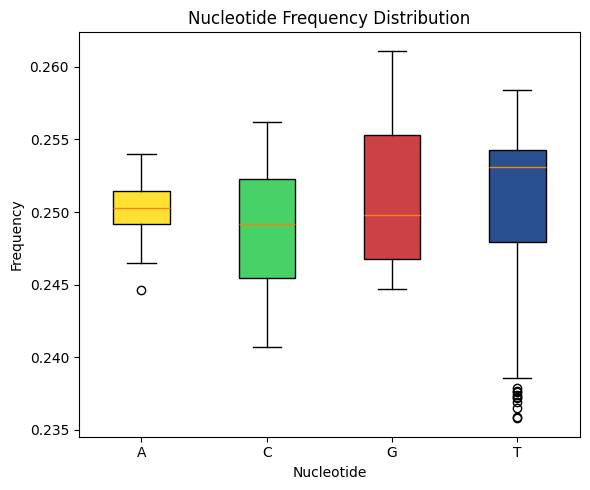

In [16]:
# Calculating frequency of each unique character in the sequences
for nuc in sorted(unique_characters):
    data[f"freq_{nuc}"] = data["Sequence"].apply(lambda s: s.count(nuc) / len(s))
fig, ax = plt.subplots(figsize=(6, 5))
freq_data = [data[f"freq_{n}"].values for n in sorted(unique_characters)]
bp = ax.boxplot(freq_data, labels=list(sorted(unique_characters)), patch_artist=True)
colors = ["#FFE134", "#47D167", "#CC4146", "#285091"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_title("Nucleotide Frequency Distribution")
ax.set_ylabel("Frequency")
ax.set_xlabel("Nucleotide")
plt.tight_layout()
plt.show()

**Sequence representation**

1. **Euclidean space**: k-mer frequency (composition-based)

2. **Non-Euclidean**: normalised Hamming distance (position-aware)

In [17]:
def kmer_freq_vector(seq, k, kmer_list)-> np.ndarray:
    """
    Computing k-mer frequency vector for a sequence.
    Args:
        seq (str): Input DNA sequence.
        k (int): Length of k-mers.
        kmer_list (list): List of all possible k-mers.
    Returns:
        np.ndarray: Normalized frequency vector of k-mers.
    """
    total = len(seq) - k + 1
    counts = {km: 0 for km in kmer_list}
    for i in range(total):
        tri = seq[i:i+k]
        if tri in counts:
            counts[tri] += 1
    return np.array([counts[km] / total for km in kmer_list])
def normalized_hamming(s1, s2)-> float:
    """
    Computing normalized Hamming distance between two equal-length strings.
    Args:
        s1 (str): First string.
        s2 (str): Second string.
    Returns:
        float: Normalized Hamming distance.
    """
    assert len(s1) == len(s2), "Sequences must be equal length for Hamming."
    return sum(c1 != c2 for c1, c2 in zip(s1, s2)) / len(s1)

In [18]:
# Building the k-mer frequency matrix for k=3 (Trinucleotide frequencies)
k=3
seqs = data['Sequence'].tolist()
k_mers = [''.join(p) for p in product("ACGT", repeat=k)] #4^3=64 possible trinucleotides
kmer_matrix = np.array([kmer_freq_vector(s, k, k_mers) for s in seqs])
print(f"k-mer frequency matrix shape: {kmer_matrix.shape}")

k-mer frequency matrix shape: (100, 64)


- k=3 provides a balance between capturing local sequence patterns and maintaining a dense, stable feature space. 

- *Higher k values lead to sparse representations* given finite sequence length, while *lower k values fail to capture sufficient contextual information*.

- Also DNA is read in codons (triplets) so k=3 is biologically justified.

1. **Euclidean Distance**

In [19]:
# K-mer space so it captures feature similarity
euclidean_matrix = pairwise_distances(kmer_matrix, metric="euclidean")
print(f"Euclidean distance matrix shape: {euclidean_matrix.shape}")
print(f"Mean pairwise Euclidean distance: {euclidean_matrix[euclidean_matrix > 0].mean():.4f}")

Euclidean distance matrix shape: (100, 100)
Mean pairwise Euclidean distance: 0.0120


- Mean pairwise Euclidean distance is very small (0.0120) indicating that the vectors are compositionally similar across all sequences.
- Differences in trinucleotide usage are subtle, making Euclidean distance a weak separator.

2. **Normalized Hamming distance matrix (Non-euclidean distance)**

In [20]:
# sequence space so it captures positional dissimilarity 
hamming_matrix = np.zeros((len(seqs), len(seqs)))
for i in range(len(seqs)):
    for j in range(i + 1, len(seqs)):
        d = normalized_hamming(seqs[i], seqs[j])
        hamming_matrix[i, j] = d
        hamming_matrix[j, i] = d
print(f"Hamming distance matrix shape: {hamming_matrix.shape}")
print(f"Mean pairwise distance: {hamming_matrix[hamming_matrix > 0].mean():.4f}")

Hamming distance matrix shape: (100, 100)
Mean pairwise distance: 0.5829


- Mean pairwise Hamming distance of 0.5829 indicates sequences differ at ~58% of positions on average.
- Strong signal for clustering as sequences are well separated at the positional level

**Hyper-parameter Selection**

- Dendogram is used to identify plausible cut points via linkage distance gaps.

In [21]:
condensed_euc=squareform(euclidean_matrix)
linkage_euc=linkage(condensed_euc,method="average")
condensed_ham=squareform(hamming_matrix)
linkage_ham=linkage(condensed_ham,method="average")

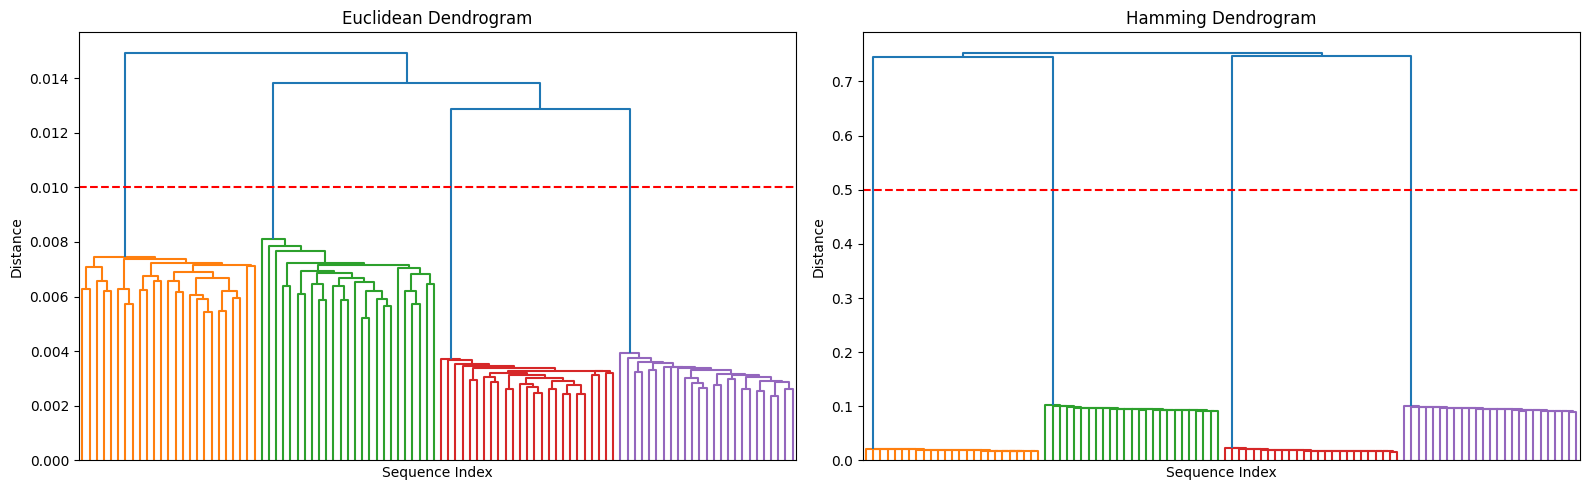

In [22]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
dendrogram(linkage_euc,ax=ax[0],no_labels=True)
ax[0].set_title("Euclidean Dendrogram")
ax[0].set_xlabel("Sequence Index")
ax[0].set_ylabel("Distance")
ax[0].axhline(y=0.010,color="red",linestyle="--")
dendrogram(linkage_ham,ax=ax[1],no_labels=True)
ax[1].set_title("Hamming Dendrogram")
ax[1].set_xlabel("Sequence Index")
ax[1].set_ylabel("Distance")
ax[1].axhline(y=0.5,color="red",linestyle="--")
plt.tight_layout()
plt.show()

- Both dendrograms independently identify 4 distinct clusters.
- Hamming separation is far sharper, reinforcing it as the stronger metric for this dataset
- Red dashed lines (t=0.5 Hamming, t=0.010 Euclidean) sit cleanly within the largest gap in both.

In [23]:
t_euc=0.010
t_ham=0.5

**Clustering**

In [24]:
# Applying hierarchical clustering (average linkage) on Euclidean distance matrix
condensed_euc = squareform(euclidean_matrix)
linkage_euc = linkage(condensed_euc, method="average")
euclidean_labels = fcluster(linkage_euc, t=t_euc, criterion="distance")
data["cluster_euclidean"] = euclidean_labels
print(f"Euclidean hierarchical counts:\n{pd.Series(euclidean_labels).value_counts()}")

Euclidean hierarchical counts:
4    25
3    25
2    25
1    25
Name: count, dtype: int64


In [25]:
# Applying hierarchical clustering (average linkage) on Hamming distance matrix
condensed_ham = squareform(hamming_matrix)
linkage_ham = linkage(condensed_ham, method="average")
hamming_labels = fcluster(linkage_ham, t=t_ham, criterion="distance")
data["cluster_hamming"] = hamming_labels
print(f"Hamming hierarchical counts:\n{pd.Series(hamming_labels).value_counts()}")


Hamming hierarchical counts:
1    25
3    25
4    25
2    25
Name: count, dtype: int64


In [26]:
# Applying HDBSCAN on precomputed Hamming matrix (density-based, no cluster count assumption)
clusterer = hdbscan.HDBSCAN(metric="precomputed", min_cluster_size=5, min_samples=3)
hdbscan_labels = clusterer.fit_predict(hamming_matrix)
data["cluster_hdbscan"] = hdbscan_labels
print(f"HDBSCAN counts (-1 = noise):\n{pd.Series(hdbscan_labels).value_counts()}")

HDBSCAN counts (-1 = noise):
0    25
3    25
2    25
1    25
Name: count, dtype: int64


**Visualisations**

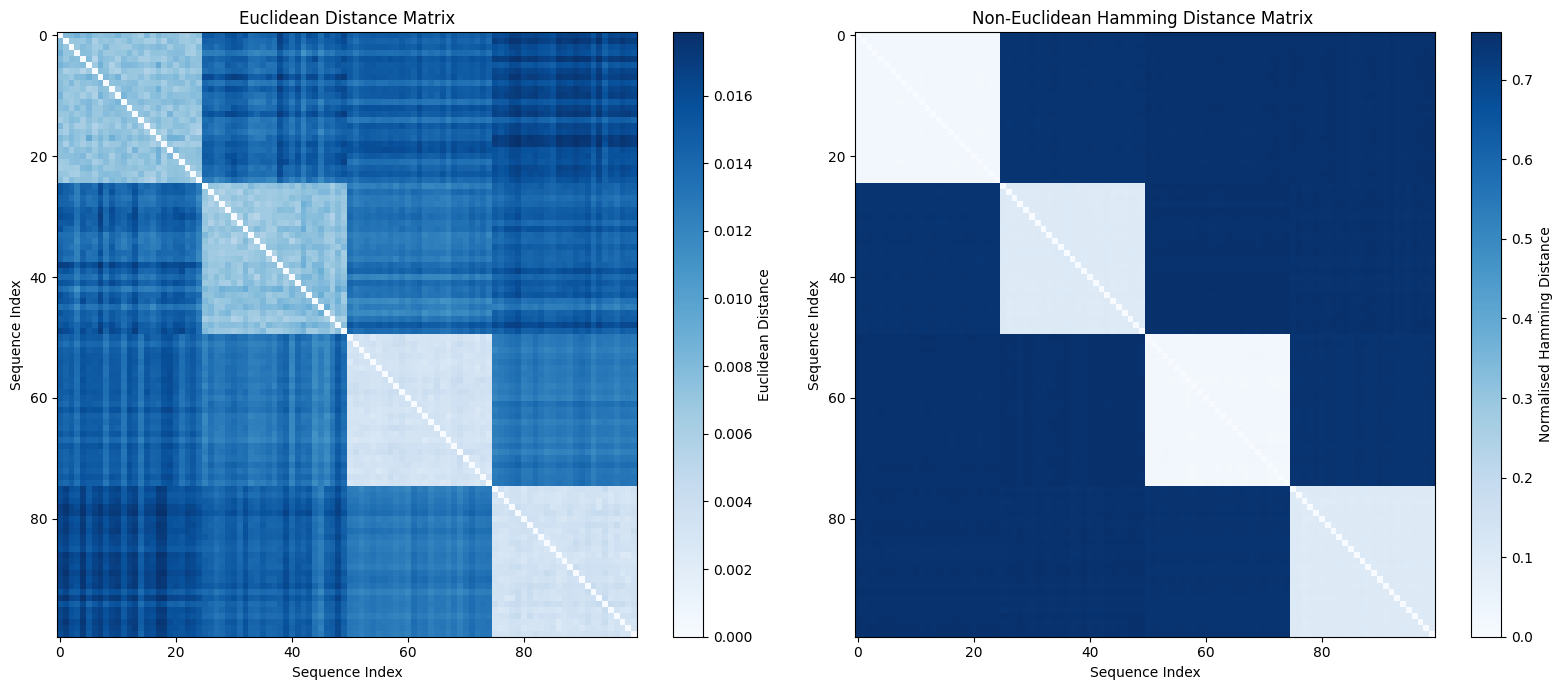

In [27]:
# Plotting Hamming and Euclidean distance matrices reordered by their respective cluster labels
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
order_ham = np.argsort(hamming_labels)
reordered_ham = hamming_matrix[np.ix_(order_ham, order_ham)]
im1 = axes[1].imshow(reordered_ham, cmap="Blues", aspect="auto")
plt.colorbar(im1, ax=axes[1], label="Normalised Hamming Distance")
axes[1].set_title("Non-Euclidean Hamming Distance Matrix ")
axes[1].set_xlabel("Sequence Index")
axes[1].set_ylabel("Sequence Index")
order_euc = np.argsort(euclidean_labels)
reordered_euc = euclidean_matrix[np.ix_(order_euc, order_euc)]
im2 = axes[0].imshow(reordered_euc, cmap="Blues", aspect="auto")
plt.colorbar(im2, ax=axes[0], label="Euclidean Distance")
axes[0].set_title("Euclidean Distance Matrix")
axes[0].set_xlabel("Sequence Index")
axes[0].set_ylabel("Sequence Index")
plt.tight_layout()
plt.show()

- Both matrices show a clear block-diagonal structure, indicating four well-defined clusters.
- Low intra-cluster distances (light blocks) and high inter-cluster distances (dark regions) confirm strong separation.
- The Hamming matrix shows sharper contrast, suggesting clusters differ strongly at the positional sequence level.
- The consistent structure across both metrics indicates robust clustering independent of representation.

In [28]:
# Projecting k-mer matrix to 2D using UMAP for visualisation
reducer = umap.UMAP(n_components=2, random_state=42, metric="euclidean")
embedding = reducer.fit_transform(kmer_matrix)
data["umap_x"] = embedding[:, 0]
data["umap_y"] = embedding[:, 1]

In [29]:
palette = plt.cm.Set2.colors
def align_labels(ref, other) -> dict:
    """
    Aligning cluster labels from other to reference using Hungarian algorithm.
    Args:
        ref (np.ndarray): Reference cluster labels.
        other (np.ndarray): Cluster labels to be aligned.
    Returns:
        dict: Mapping from other label values to reference label values.
    """
    mask = other != -1
    ref_labels = sorted(set(ref[mask]))
    other_labels = sorted(set(other[mask]))
    cm = confusion_matrix(ref[mask], other[mask], labels=ref_labels)
    r, c = linear_sum_assignment(-cm)
    return {other_labels[c[i]]: ref_labels[r[i]] for i in range(len(r))}

In [30]:
# Aligning Euclidean and HDBSCAN labels to Hamming as reference
map_euc = align_labels(hamming_labels, euclidean_labels)
map_hdb = align_labels(hamming_labels, hdbscan_labels)

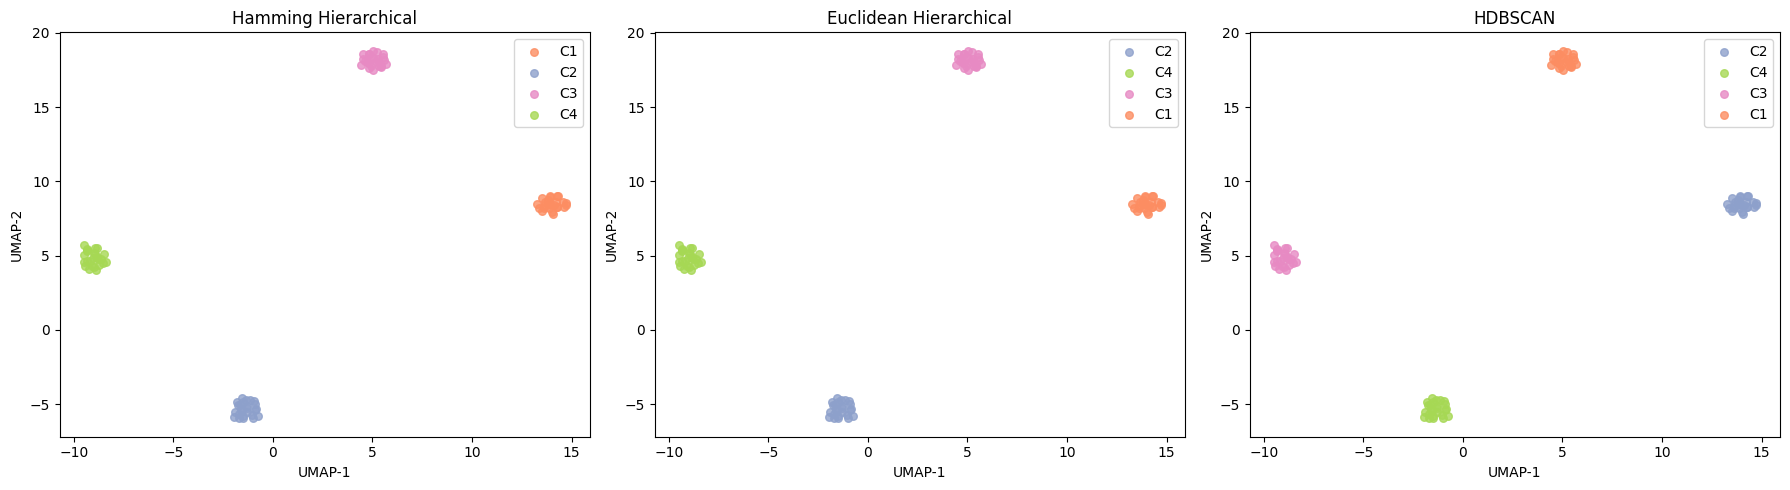

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# Plotting Hamming hierarchical (reference, no remapping needed)
for l in sorted(set(hamming_labels)):
    m = hamming_labels == l
    ax[0].scatter(embedding[m, 0], embedding[m, 1],
                  c=[palette[l % len(palette)]], s=30, alpha=0.8, label=f"C{l}")
ax[0].set_title("Hamming Hierarchical")

# Plotting Euclidean hierarchical (aligned to Hamming)
for l in sorted(set(euclidean_labels)):
    m = euclidean_labels == l
    l_mapped = map_euc.get(l, l)
    ax[1].scatter(embedding[m, 0], embedding[m, 1],
                  c=[palette[l_mapped % len(palette)]], s=30, alpha=0.8, label=f"C{l_mapped}")
ax[1].set_title("Euclidean Hierarchical")

# Plotting HDBSCAN (aligned to Hamming, noise in grey)
for l in sorted(set(hdbscan_labels)):
    m = hdbscan_labels == l
    if l == -1:
        ax[2].scatter(embedding[m, 0], embedding[m, 1],
                      c=["grey"], s=30, alpha=0.8, label="Noise")
    else:
        l_mapped = map_hdb.get(l, l)
        ax[2].scatter(embedding[m, 0], embedding[m, 1],
                      c=[palette[l_mapped % len(palette)]], s=30, alpha=0.8, label=f"C{l_mapped}")
ax[2].set_title("HDBSCAN")
for a in ax:
    a.set_xlabel("UMAP-1")
    a.set_ylabel("UMAP-2")
    a.legend()
plt.tight_layout()
plt.show()

- All three methods (Hamming hierarchical, Euclidean hierarchical, and HDBSCAN) recover the same four well-separated clusters.

- Cluster locations are consistent across methods, indicating strong agreement despite different distance metrics and algorithms.

- The absence of noise points in HDBSCAN further indicates that the dataset contains well-defined, homogeneous groups.

**The convergence of multiple methods on identical cluster structure provides strong evidence for a robust and biologically meaningful grouping of the sequences**

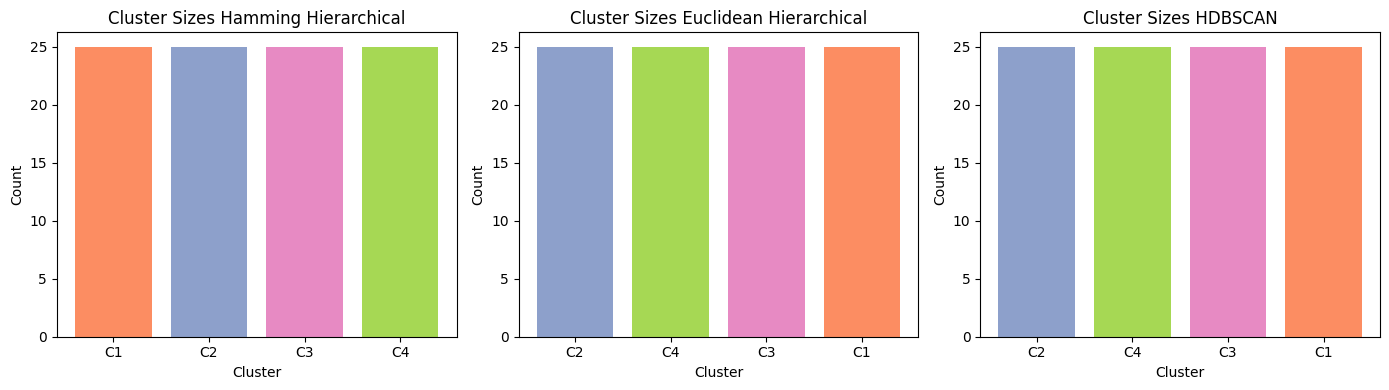

In [32]:
# Plotting cluster size distribution for all three methods with aligned colours
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, labels, mapping, title in zip(axes,
    [hamming_labels, euclidean_labels, hdbscan_labels],
    [None, map_euc, map_hdb],
    ["Hamming Hierarchical", "Euclidean Hierarchical", "HDBSCAN"]):
    counts = pd.Series(labels).value_counts().sort_index()
    labels_str = []
    bar_colors = []
    for l in counts.index:
        if l == -1:
            labels_str.append("Noise")
            bar_colors.append("grey")
        else:
            l_mapped = mapping.get(l, l) if mapping else l
            labels_str.append(f"C{l_mapped}")
            bar_colors.append(palette[l_mapped % len(palette)])
    ax.bar(labels_str, counts.values, color=bar_colors)
    ax.set_title(f"Cluster Sizes {title}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

- All methods produce four clusters of equal size (~25 sequences each).
- The absence of imbalance or dominant clusters suggests the data is well-structured rather than skewed or noisy.
- This uniformity supports the presence of distinct, equally represented groups within the dataset.

**Cluster validation**

In [33]:
# Computing silhouette scores on Hamming precomputed matrix
mask_valid = hdbscan_labels != -1
sil_hdbscan = silhouette_score(hamming_matrix[np.ix_(mask_valid, mask_valid)],hdbscan_labels[mask_valid],metric="precomputed")
sil_hamming = silhouette_score(hamming_matrix, hamming_labels, metric="precomputed")
sil_euclidean = silhouette_score(hamming_matrix, euclidean_labels, metric="precomputed")
print(f"Silhouette HDBSCAN (Hamming):{sil_hdbscan:.4f}")
print(f"Silhouette Hamming Hierarchical:{sil_hamming:.4f}")
print(f"Silhouette Euclidean Hierarchical:{sil_euclidean:.4f}")

Silhouette HDBSCAN (Hamming):0.9219
Silhouette Hamming Hierarchical:0.9219
Silhouette Euclidean Hierarchical:0.9219


- All methods achieve a high silhouette score (~0.92), indicating strong cluster separation and cohesion.
- The identical scores across methods further confirm that the clustering structure is consistent and not dependent on the choice of algorithm or distance metric.

In [34]:
# Computing Davies-Bouldin and Calinski-Harabasz on k-mer Euclidean space
db_ham = davies_bouldin_score(kmer_matrix, hamming_labels)
db_euc = davies_bouldin_score(kmer_matrix, euclidean_labels)
ch_ham = calinski_harabasz_score(kmer_matrix, hamming_labels)
ch_euc = calinski_harabasz_score(kmer_matrix, euclidean_labels)
print(f"Davies-Bouldin  (lower = better) Hamming:   {db_ham:.4f}")
print(f"Davies-Bouldin  (lower = better)  Euclidean: {db_euc:.4f}")
print(f"Calinski-Harabasz (higher = better) Hamming:   {ch_ham:.4f}")
print(f"Calinski-Harabasz (higher = better) Euclidean: {ch_euc:.4f}")


Davies-Bouldin  (lower = better) Hamming:   0.6894
Davies-Bouldin  (lower = better)  Euclidean: 0.6894
Calinski-Harabasz (higher = better) Hamming:   136.9952
Calinski-Harabasz (higher = better) Euclidean: 136.9952


- The low Davies–Bouldin score (~0.69) indicates compact and well-separated clusters, while the high Calinski–Harabasz score (~137) reflects strong between-cluster separation relative to within-cluster variance.

**Within cluster sequence analysis**

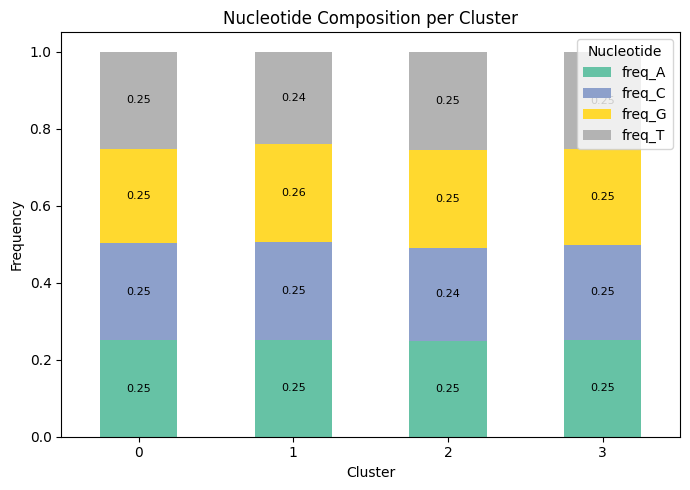

In [35]:
# Computing mean nucleotide frequencies per HDBSCAN cluster
data["cluster"] = hdbscan_labels
nuc_cols = [f"freq_{n}" for n in sorted(unique_characters)]
cluster_nuc_stats = data.groupby("cluster")[nuc_cols].mean().round(4)
ax=cluster_nuc_stats.plot(kind="bar",stacked=True,figsize=(7,5),colormap="Set2")

for i,(_,row) in enumerate(cluster_nuc_stats.iterrows()):
    cum=0
    for val in row:
        ax.text(i,cum+val/2,f"{val:.2f}",ha="center",va="center",fontsize=8,color="black")
        cum+=val
plt.title("Nucleotide Composition per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.legend(title="Nucleotide")
plt.tight_layout()
plt.show()

The uniform nucleotide composition further confirms that the identified clusters reflect deeper structural differences within the sequences.

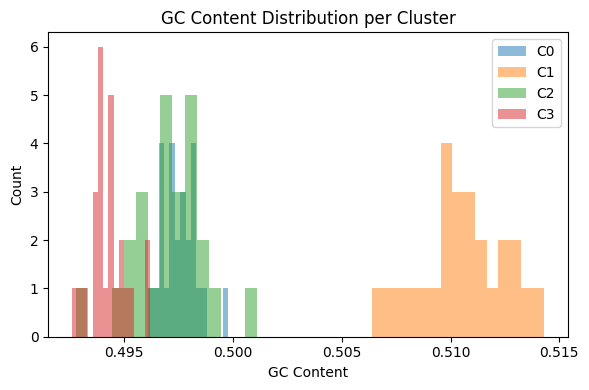

In [36]:
# Computing GC content per cluster
data["gc_content"] = data["Sequence"].apply(
    lambda s: (s.count("G") + s.count("C")) / len(s))
gc_per_cluster = data.groupby("cluster")["gc_content"].agg(["mean", "std"]).round(4)
plt.figure(figsize=(6,4))
for l in sorted(data["cluster"].unique()):
    subset=data[data["cluster"]==l]["gc_content"]
    plt.hist(subset,bins=15,alpha=0.5,label=f"C{l}")
plt.title("GC Content Distribution per Cluster")
plt.xlabel("GC Content")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Identifying medoid (most central sequence) per cluster using Hamming matrix
print("Medoids per cluster:")
for label in sorted(set(hdbscan_labels)):
    if label == -1:
        continue
    indices = np.where(hdbscan_labels == label)[0]
    sub_matrix = hamming_matrix[np.ix_(indices, indices)]
    medoid_local = np.argmin(sub_matrix.sum(axis=1))
    medoid_global = indices[medoid_local]
    print(f"Cluster {label}: index {medoid_global} | {seqs[medoid_global][:50]}...")

Medoids per cluster:
Cluster 0: index 21 | CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAATAGG...
Cluster 1: index 91 | GGAGGCTTGAGGTTCAGTATCCCCCAGTGCATGACCGGGTGGTTAATGTC...
Cluster 2: index 50 | AAAGGAGGTTTCGCGAAGTGGGTGATAGCAGATGGTAGCCGGCCCATCGG...
Cluster 3: index 25 | TTGCCGGACGTTCCCAGACCTCCGAATGTGAACTTCGTTCACTTCTGAAT...


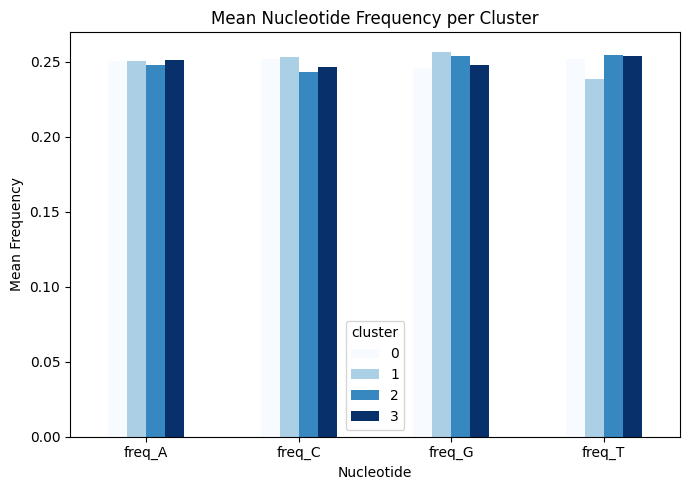

In [38]:
# Plotting mean nucleotide frequencies per cluster as grouped bar chart
cluster_nuc_stats.T.plot(kind="bar", figsize=(7, 5), colormap="Blues")
plt.title("Mean Nucleotide Frequency per Cluster")
plt.xlabel("Nucleotide")
plt.ylabel("Mean Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- All clusters exhibit near-uniform nucleotide frequencies (~25%) across A, C, G, and T.
- Only minor variations are observed, with no nucleotide showing a strong deviation in any cluster.
- This indicates that clustering is not driven by overall nucleotide composition.
- The consistency in frequencies further confirms that the separation arises from more subtle sequence features, such as positional patterns.

**Conclusion**

- Two complementary representations were compared: k-mer frequency (Euclidean) capturing compositional patterns, and Hamming distance capturing positional sequence differences.

- Both distance measures produced consistent distance structures, with clear block patterns indicating well-separated groups.

- Hierarchical clustering (Euclidean and Hamming) and HDBSCAN all identified four distinct clusters, with identical cluster sizes and no noise points.
The agreement across different clustering methods indicates that the structure is robust and not method-dependent.

- Visualisations (distance heatmaps, dendrograms, UMAP) show clear separation and compact clusters, supporting the clustering results qualitatively.

- Validation metrics further confirm this:
    - High silhouette (~0.92) → strong separation
    - Low Davies–Bouldin (~0.69) → compact clusters
    - High Calinski–Harabasz (~137) → strong between-cluster variance

- Identical scores across methods → consistent structure

- Nucleotide frequency and GC content analyses show near-uniform composition across clusters, indicating that clustering is not driven by simple base composition.

- This further confirms that clusters are defined by more subtle features, such as sequence patterns or positional structure.

**Take-away**

**1. Regularization**

- Lasso, Ridge and Elastic Net behave differently. Ridge is robust to multicollinearity but does not improve interpretability; Lasso improves interpretability but can remove too many useful features; Elastic Net balances sparsity and stability and is well-suited for correlated data
- Fueature selection is not unique. Among correlated features, Lasso selects one representative per correlated group
- In the highly correlated dataset, most predictive information is concentrated in few features, both Lasso and Elastic Net maintain a stable performance with less than 50 features

**2. Distances**

- 
- 